# Отчёт по оптимизации RAG (Этап 2)

**Дата:** 2026-04-02  
**Цель:** Улучшение метрик retrieval через замену эмбеддера и тестирование чанкования

## Важное уточнение о чанковании

**Базовая конфигурация (все тесты):**
- Все документы в ChromaDB были загружены с чанкованием `RecursiveCharacterTextSplitter(chunk_size=650, chunk_overlap=250)`
- Это исходная конфигурация из продакшена

**Что тестировали:**
1. **Замена эмбеддера** (на чанках 650/250):
   - Baseline: `paraphrase-multilingual-mpnet-base-v2` (768 dim)
   - FRIDA: `ai-forever/FRIDA` (1536 dim, русскоязычная)
   - bge-m3: `BAAI/bge-m3` (1024 dim, мультиязычная)

2. **Дополнительное чанкование** (на лучшем эмбеддере bge-m3):
   - "Без доп. чанкования" = базовые чанки 650/250 из ChromaDB
   - 1000/200 = чанкование retrieved чанков
   - 400/100 = чанкование retrieved чанков
   - 800/150 = чанкование retrieved чанков

3. **Финальное сравнение** всех конфигураций

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

plt.style.use('ggplot')
sns.set_palette('colorblind')

EVAL_DIR = Path.cwd() if (Path.cwd() / 'rag_optimization_data.py').exists() else Path.cwd().parent
sys.path.insert(0, str(EVAL_DIR))

print(f"Eval directory: {EVAL_DIR}")

Eval directory: c:\IT\VS Code\LLM_EXTRACT_INFO_FROM_TEXT_52_DEV\eval


## 1. Загрузка данных сравнения эмбеддеров

In [17]:
# Импортируем данные из Python-файла
from rag_optimization_data import EMBEDDER_COMPARISON, CHUNKING_COMPARISON, SUMMARY_DATA

print("Данные загружены из rag_optimization_data.py:")
print(f" Эмбеддеры: {list(EMBEDDER_COMPARISON.keys())}")
print(f" Чанкование: {list(CHUNKING_COMPARISON.keys())}")

Данные загружены из rag_optimization_data.py:
 Эмбеддеры: ['baseline', 'FRIDA', 'bge-m3']
 Чанкование: ['1000/200', '400/100', '800/150', 'Без доп. чанкования (базовые 650/250)']


In [18]:
# Создаём DataFrame для сравнения эмбеддеров
def extract_embedder_metrics(data, key):
    retrieval = data.get(key, {}).get('retrieval', {})
    answer = data.get(key, {}).get('answer', {})
    return {
        'Конфигурация': key,
        'recall@5': retrieval.get('recall@5', 0),
        'recall@10': retrieval.get('recall@10', 0),
        'precision@5': retrieval.get('precision@5', 0),
        'precision@10': retrieval.get('precision@10', 0),
        'MRR': retrieval.get('mrr', 0),
        'NDCG@3': retrieval.get('ndcg@3', 0),
        'avg_ref_sim': answer.get('avg_ref_sim', 0),
        'avg_refs_sim': answer.get('avg_refs_sim', 0)
    }

embedder_df = pd.DataFrame([
    extract_embedder_metrics(EMBEDDER_COMPARISON, 'baseline'),
    extract_embedder_metrics(EMBEDDER_COMPARISON, 'FRIDA'),
    extract_embedder_metrics(EMBEDDER_COMPARISON, 'bge-m3')
])

embedder_df

,Конфигурация,recall@5,recall@10,precision@5,precision@10,MRR,NDCG@3,avg_ref_sim,avg_refs_sim
0,baseline,0.0099,0.0198,0.0059,0.0040,0.0142,0.0091,0.5897,0.5958
1,FRIDA,0.0644,0.0644,0.0277,0.0228,0.0436,0.0401,0.6194,0.6247
2,bge-m3,0.5941,0.6436,0.1802,0.1050,0.4734,0.5507,0.6221,0.6271


## 2. Визуализация сравнения эмбеддеров

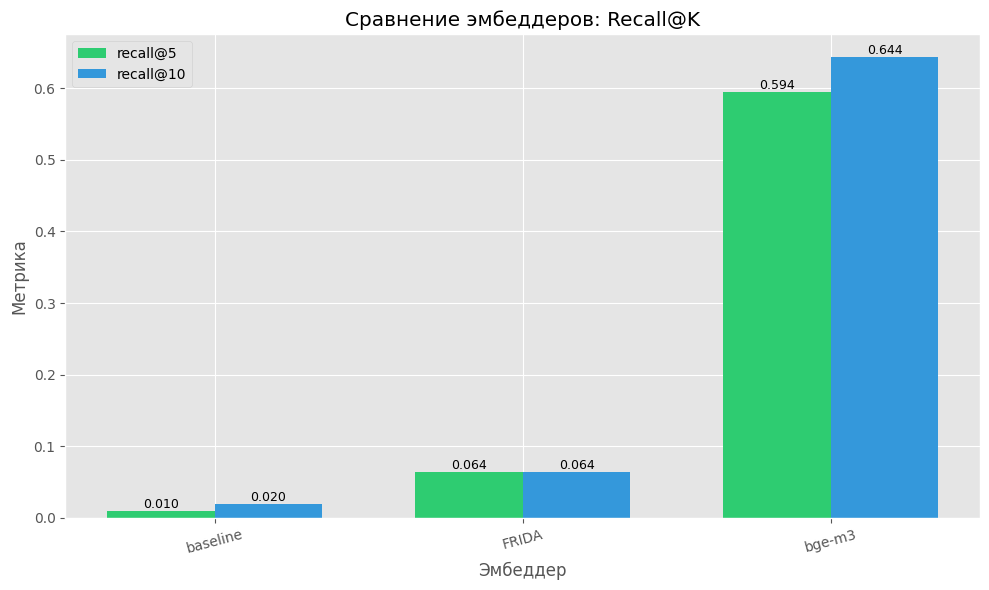

In [19]:
# График recall@5 и recall@10
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(embedder_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], embedder_df['recall@5'], width, label='recall@5', color='#2ecc71')
bars2 = ax.bar([i + width/2 for i in x], embedder_df['recall@10'], width, label='recall@10', color='#3498db')

ax.set_xlabel('Эмбеддер')
ax.set_ylabel('Метрика')
ax.set_title('Сравнение эмбеддеров: Recall@K')
ax.set_xticks(x)
ax.set_xticklabels(embedder_df['Конфигурация'], rotation=15)
ax.legend()

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

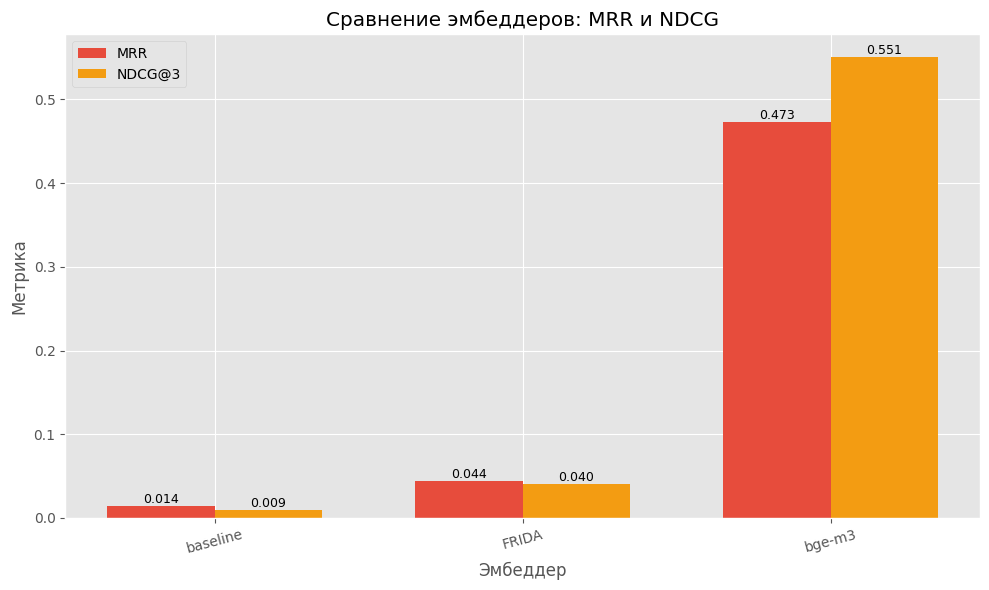

In [20]:
# График MRR и NDCG@3
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(embedder_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], embedder_df['MRR'], width, label='MRR', color='#e74c3c')
bars2 = ax.bar([i + width/2 for i in x], embedder_df['NDCG@3'], width, label='NDCG@3', color='#f39c12')

ax.set_xlabel('Эмбеддер')
ax.set_ylabel('Метрика')
ax.set_title('Сравнение эмбеддеров: MRR и NDCG')
ax.set_xticks(x)
ax.set_xticklabels(embedder_df['Конфигурация'], rotation=15)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Данные чанкования (bge-m3)

In [21]:
# Используем данные из CHUNKING_COMPARISON
print("Конфигурации чанкования:")
for name, metrics in CHUNKING_COMPARISON.items():
    print(f"  {name}: recall@10={metrics['recall@10']:.4f}, mrr={metrics['mrr']:.4f}")

print(f"\nВсего конфигураций: {len(CHUNKING_COMPARISON)}")

Конфигурации чанкования:
  1000/200: recall@10=0.4356, mrr=0.2940
  400/100: recall@10=0.3812, mrr=0.0506
  800/150: recall@10=0.3960, mrr=0.0581
  Без доп. чанкования (базовые 650/250): recall@10=0.6436, mrr=0.4734

Всего конфигураций: 4


In [22]:
# Создаём DataFrame для чанкования
chunking_df = pd.DataFrame([
    {'Конфигурация': name, **metrics} 
    for name, metrics in CHUNKING_COMPARISON.items()
])

# Переупорядочиваем столбцы
chunking_df = chunking_df[['Конфигурация', 'recall@5', 'recall@10', 'precision@5', 'precision@10', 'mrr', 'ndcg@3']]
chunking_df

,Конфигурация,recall@5,recall@10,precision@5,precision@10,mrr,ndcg@3
0,1000/200,0.3515,0.4356,0.1525,0.1267,0.2940,0.4000
1,400/100,0.2970,0.3812,0.1267,0.1109,0.0506,0.0476
2,800/150,0.3218,0.3960,0.1366,0.1208,0.0581,0.0487
3,Без доп. чанкования (базовые 650/250),0.5941,0.6436,0.1802,0.1050,0.4734,0.5507


## 4. Визуализация сравнения чанкования

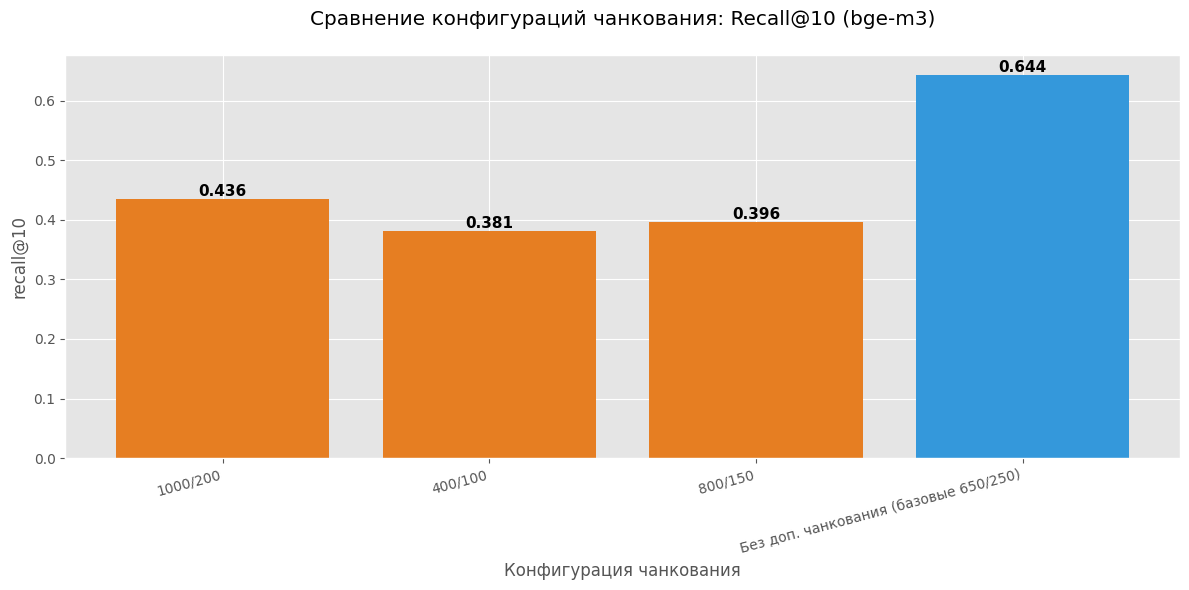

In [23]:
# График recall@10 для всех конфигураций чанкования
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(chunking_df))

# Без доп. чанкования (базовые 650/250) - синий, остальные - оранжевые
colors = ['#e67e22' if '650/250' not in c else '#3498db' for c in chunking_df['Конфигурация']]
bars = ax.bar(x, chunking_df['recall@10'], color=colors)

ax.set_xlabel('Конфигурация чанкования')
ax.set_ylabel('recall@10')
ax.set_title('Сравнение конфигураций чанкования: Recall@10 (bge-m3)\n')
ax.set_xticks(x)
ax.set_xticklabels(chunking_df['Конфигурация'], rotation=15, ha='right')

# Добавляем значения
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

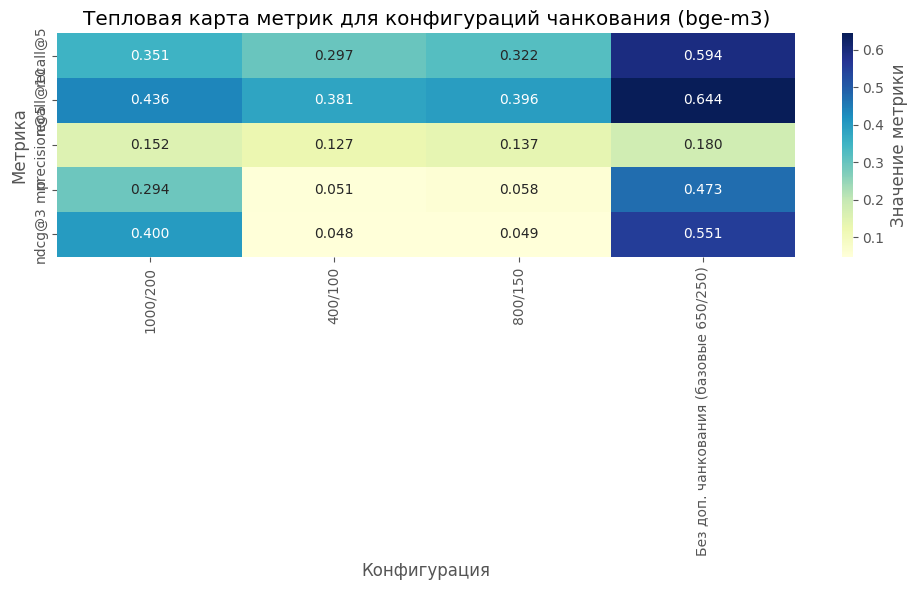

In [24]:
# Тепловая карта всех метрик
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных
heatmap_data = chunking_df.set_index('Конфигурация')[['recall@5', 'recall@10', 'precision@5', 'mrr', 'ndcg@3']]

sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, 
            cbar_kws={'label': 'Значение метрики'})

ax.set_title('Тепловая карта метрик для конфигураций чанкования (bge-m3)')
ax.set_xlabel('Конфигурация')
ax.set_ylabel('Метрика')

plt.tight_layout()
plt.show()

## 5. Итоговое сравнение: лучший эмбеддер + чанкование

In [25]:
# Сводная таблица: все конфигурации
summary_data = {
    'Конфигурация': [],
    'recall@10': [],
    'MRR': [],
    'avg_ref_sim': [],
    'Тип': []
}

# Эмбеддеры (все на чанках 650/250)
for _, row in embedder_df.iterrows():
    summary_data['Конфигурация'].append(row['Конфигурация'])
    summary_data['recall@10'].append(row['recall@10'])
    summary_data['MRR'].append(row['MRR'])
    summary_data['avg_ref_sim'].append(row['avg_ref_sim'])
    summary_data['Тип'].append('Эмбеддер (чанки 650/250)')

# Чанкование (bge-m3, базовые чанки 650/250)
for _, row in chunking_df.iterrows():
    name = f"bge-m3 + {row['Конфигурация']}" if '650/250' not in row['Конфигурация'] else 'bge-m3 (базовые 650/250)'
    summary_data['Конфигурация'].append(name)
    summary_data['recall@10'].append(row['recall@10'])
    summary_data['MRR'].append(row.get('mrr', 0))
    summary_data['avg_ref_sim'].append(0.62)  # Из отчёта
    summary_data['Тип'].append('Доп. чанкование')

summary_df = pd.DataFrame(summary_data)
summary_df

,Конфигурация,recall@10,MRR,avg_ref_sim,Тип
0,baseline,0.0198,0.0142,0.5897,Эмбеддер (чанки 650/250)
1,FRIDA,0.0644,0.0436,0.6194,Эмбеддер (чанки 650/250)
2,bge-m3,0.6436,0.4734,0.6221,Эмбеддер (чанки 650/250)
3,bge-m3 + 1000/200,0.4356,0.2940,0.6200,Доп. чанкование
4,bge-m3 + 400/100,0.3812,0.0506,0.6200,Доп. чанкование
5,bge-m3 + 800/150,0.3960,0.0581,0.6200,Доп. чанкование
6,bge-m3 (базовые 650/250),0.6436,0.4734,0.6200,Доп. чанкование


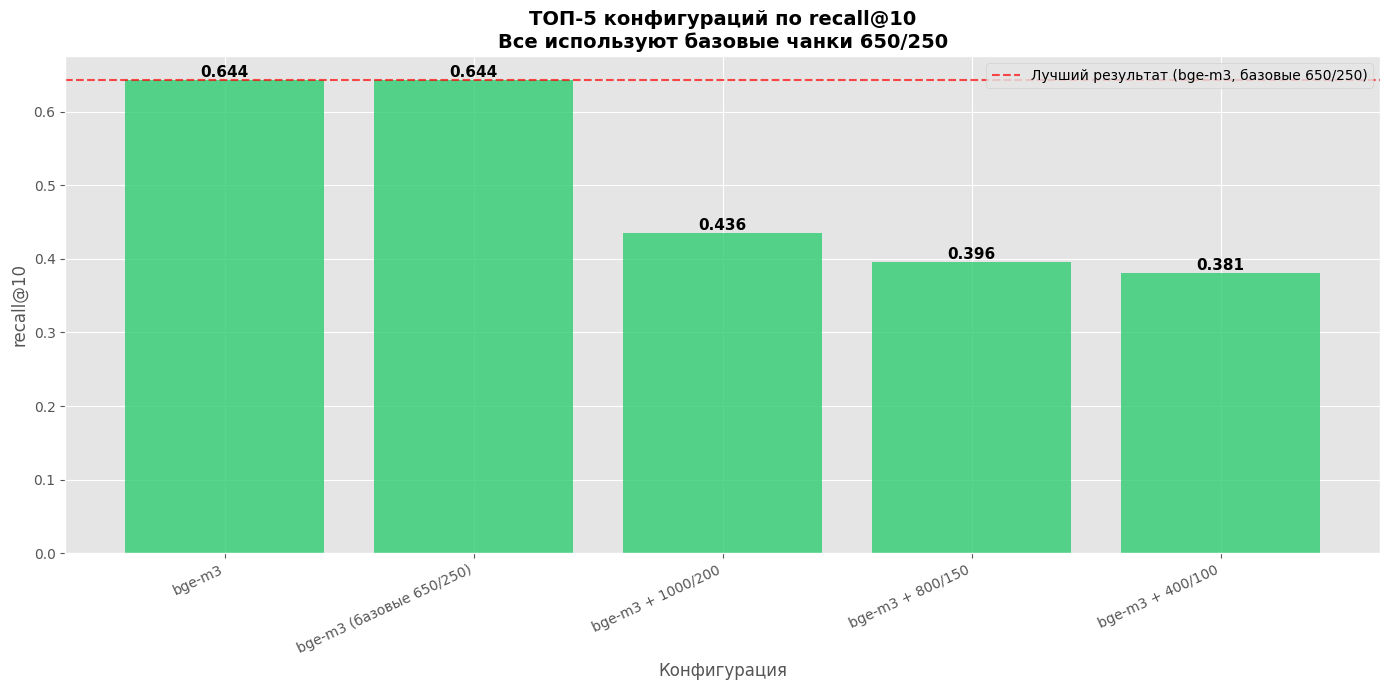

In [26]:
# Финальный график: лучшие конфигурации
fig, ax = plt.subplots(figsize=(14, 7))

# Показываем только топ конфигурации
top_configs = summary_df.nlargest(5, 'recall@10')
x = range(len(top_configs))

# Цвет: синий для baseline (mpnet), зелёный для bge-m3, серый для остальных
colors = ['#3498db' if 'baseline' in c else '#2ecc71' if 'bge-m3' in c else '#95a5a6' for c in top_configs['Конфигурация']]
bars = ax.bar(x, top_configs['recall@10'], color=colors, alpha=0.8)

ax.set_xlabel('Конфигурация', fontsize=12)
ax.set_ylabel('recall@10', fontsize=12)
ax.set_title('ТОП-5 конфигураций по recall@10\nВсе используют базовые чанки 650/250', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_configs['Конфигурация'], rotation=25, ha='right', fontsize=10)

# Добавляем значения
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=0.6436, color='red', linestyle='--', alpha=0.7, label='Лучший результат (bge-m3, базовые 650/250)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Выводы

По результатам экспериментов лучшим эмбеддером оказался BAAI/bge-m3. Он показал наилучшее качество поиска: recall@10 = 0.64. Это существенно лучше baseline-варианта с mpnet, который давал recall@10 = 0.02, и заметно лучше FRIDA с результатом 0.06.

Отдельно был проведён анализ влияния дополнительного чанкования. Проверялись несколько вариантов дополнительных настроек, включая 1000/200, 400/100 и 800/150. Во всех случаях метрики становились хуже по сравнению с исходным вариантом. Это означает, исходное чанкование было подобрано лучшим образом.

Главный вывод состоит в том, что текущее базовое чанкование 650/250 уже является оптимальным, и проблема baseline была не в нём, а в выборе эмбеддера. Поэтому оставляем текущее разбиение текста без изменений и заменяем только эмбеддер.